# Step 1 - Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cpu")  # CPU only
print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {device}")
print("Imports OK")

PyTorch version : 2.11.0+cpu
Device          : cpu
Imports OK


# Step 2 -Configuration

In [2]:
split_dir  = Path("../data/split")
output_dir = Path("../data/results")

nintervals  = 96     # quarter-hours per day
nfeatures   = 7      # input features
seq_days     = 7     # LSTM looks back 7 days (one full week)
random_state = 42

features = [
    "price_lag1d",
    "price_lag7d",
    "price_hourly_lag1d",
    "price_hourly_lag7d",
    "wind_mwh",
    "solar_mwh",
    "load_mwh",
]
target = "price_eur_mwh"

# LSTM architecture
hidden_size  = 64    # number of LSTM hidden units
num_layers   = 2     # number of stacked LSTM layers
dropout     = 0.2   # dropout between LSTM layers

# Training
learning_rate = 0.001
max_epochs    = 50
batch_size    = 16
patience      = 10   # early stopping patience

print(f"Sequence length : {seq_days} days = {seq_days * nintervals} intervals")
print(f"Input shape     : ({seq_days}, {nintervals}, {nfeatures}) per sample")
print(f"Output shape    : ({nintervals},) per sample")
print(f"Hidden size     : {hidden_size}")
print(f"Num layers      : {num_layers}")
print(f"Max epochs      : {max_epochs}")

Sequence length : 7 days = 672 intervals
Input shape     : (7, 96, 7) per sample
Output shape    : (96,) per sample
Hidden size     : 64
Num layers      : 2
Max epochs      : 50


# Step 3 - Load Data
Data is loaded at interval level and then reshaped into day-level arrays:
- X_day: shape (n_days, nintervals, nfeatures) — features per day
- y_days: shape (n_days, nintervals) — prices per day

In [3]:
df = pd.read_csv(split_dir / "feature_matrix_clean.csv", parse_dates=["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

train_days = [pd.Timestamp(d).date() for d in pd.read_csv(split_dir / "train_days.csv")["date"]]
test_days  = [pd.Timestamp(d).date() for d in pd.read_csv(split_dir / "test_days.csv")["date"]]
all_days   = sorted(df["timestamp"].dt.date.unique())

n_train = len(train_days)   # 100
n_test  = len(test_days)    # 44
n_total = len(all_days)     # 144

# Reshape to day level: (n_days, nintervals, nfeatures) and (n_days, nintervals)
X_days = np.zeros((n_total, nintervals, nfeatures))
y_days = np.zeros((n_total, nintervals))

# fill arrays day by day 
for i, day in enumerate(all_days):
    day_df = df[df["timestamp"].dt.date == day].sort_values("timestamp")
    X_days[i] = day_df[features].values   # (96, 7)
    y_days[i] = day_df[target].values     # (96,)

print(f"X_days shape : {X_days.shape}  (n_days, nintervals, nfeatures)")
print(f"y_days shape : {y_days.shape}  (n_days, nintervals)")

X_days shape : (144, 96, 7)  (n_days, nintervals, nfeatures)
y_days shape : (144, 96)  (n_days, nintervals)


# Step 4 - Normalisation
Mean-std standardisation using training data statistics only (Lebedev et al.)

In [4]:
X_train_raw = X_days[:n_train]   # (100, 96, 7)
y_train_raw = y_days[:n_train]   # (100, 96)

# Per-feature mean and std across all training intervals
offset_X = X_train_raw.reshape(-1, nfeatures).mean(axis=0)  # (7,)
scale_X  = X_train_raw.reshape(-1, nfeatures).std(axis=0)   # (7,)
scale_X[scale_X == 0] = 1.0

offset_y = float(y_train_raw.mean())
scale_y  = float(y_train_raw.std())

# Normalise
X_norm = (X_days - offset_X) / scale_X   # (144, 96, 7)
y_norm = (y_days - offset_y) / scale_y   # (144, 96)

print(f"offset_y (mean price) : {offset_y:.4f} EUR/MWh")
print(f"scale_y  (std price)  : {scale_y:.4f} EUR/MWh")

offset_y (mean price) : 95.2633 EUR/MWh
scale_y  (std price)  : 43.5266 EUR/MWh


# Step 5 - LSTM model 

In [8]:
# create neural network class
class LSTMForecaster(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout):
        super(LSTMForecaster, self).__init__()
        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            dropout     = dropout if num_layers > 1 else 0.0,
            batch_first = True,   # input shape: (batch, seq_len, input_size)
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        lstm_out, _ = self.lstm(x)        # process all 7 days
        last_step   = lstm_out[:, -1, :]  # take only day 7 output 
        out         = self.fc(last_step)  # convert to 96 proces
        return out


# Input: seq_days time steps, each = N_INTERVALS * N_FEATURES (flattened day)
input_size  = nintervals * nfeatures   # 96 * 7 = 672
output_size = nintervals                # 96 prices

# Instantiate model
model = LSTMForecaster(
    input_size  = input_size,
    hidden_size = hidden_size,
    num_layers  = num_layers,
    output_size = output_size,
    dropout     = dropout,
).to(device)

print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")

LSTMForecaster(
  (lstm): LSTM(672, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=96, bias=True)
)

Total parameters: 228,448


# Step 6 - Build Sequences

In [9]:
def build_sequences(X_norm, y_norm, seq_days):
    n_days = len(X_norm)
    X_seq, y_seq, day_indices = [], [], []
    for d in range(seq_days, n_days):
        seq = X_norm[d - seq_days:d]           # (seq_days, nintervals, nfeatures)
        seq_flat = seq.reshape(seq_days, -1)   # (seq_days, nintervals * nfeatures)
        X_seq.append(seq_flat)
        y_seq.append(y_norm[d])
        day_indices.append(d)
    return np.array(X_seq), np.array(y_seq), day_indices


X_seq, y_seq, day_indices = build_sequences(X_norm, y_norm, seq_days)

print(f"X_seq shape : {X_seq.shape}  (n_samples, seq_days, input_size)")
print(f"y_seq shape : {y_seq.shape}  (n_samples, nintervals)")
print(f"First usable day index : {day_indices[0]} (day {seq_days + 1} of 144)")

X_seq shape : (137, 7, 672)  (n_samples, seq_days, input_size)
y_seq shape : (137, 96)  (n_samples, nintervals)
First usable day index : 7 (day 8 of 144)


# Step 7 - Expanding- Window Training and Evaluation

In [11]:
lstm_predictions = np.zeros((n_test, nintervals))

for i in range(n_test):
    # Current forecast day index in the full dataset
    forecast_day_idx = n_train + i

    # All sequences where the target day is before the forecast day
    train_mask = [idx < forecast_day_idx for idx in day_indices]
    X_train_seq = X_seq[train_mask]
    y_train_seq = y_seq[train_mask]

    # Convert to tensors
    X_tr = torch.tensor(X_train_seq, dtype=torch.float32).to(device)
    y_tr = torch.tensor(y_train_seq, dtype=torch.float32).to(device)

    # Use last 10% of training as validation for early stopping
    n_val   = max(1, int(0.1 * len(X_tr)))
    X_val   = X_tr[-n_val:]
    y_val   = y_tr[-n_val:]
    X_tr    = X_tr[:-n_val]
    y_tr    = y_tr[:-n_val]

    # DataLoader
    train_ds     = TensorDataset(X_tr, y_tr)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    # Fresh model for each forecast origin
    torch.manual_seed(random_state)
    lstm_model = LSTMForecaster(
        input_size  = input_size,
        hidden_size = hidden_size,
        num_layers  = num_layers,
        output_size = output_size,
        dropout     = dropout,
    ).to(device)

    optimizer = torch.optim.Adam(lstm_model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()

    # Training loop with early stopping
    best_val_loss = float("inf")
    patience_counter = 0
    best_state = None

    for epoch in range(max_epochs):
        # Train
        lstm_model.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            pred = lstm_model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            optimizer.step()

        # Validate
        lstm_model.eval()
        with torch.no_grad():
            val_pred = lstm_model(X_val)
            val_loss = criterion(val_pred, y_val).item()

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            patience_counter = 0
            best_state       = {k: v.clone() for k, v in lstm_model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    # Restore best model and predict
    lstm_model.load_state_dict(best_state)
    lstm_model.eval()

    X_pred = torch.tensor(
        X_seq[day_indices.index(forecast_day_idx)][np.newaxis, :, :],
        dtype=torch.float32
    ).to(device)

    with torch.no_grad():
        lstm_predictions[i] = lstm_model(X_pred).cpu().numpy()

    if (i + 1) % 5 == 0 or i == 0:
        print(f"  Test day {i+1:>2d}/44 done  (trained on {len(X_train_seq)} sequences, stopped at epoch {epoch+1})")

print("\nAll test days done")

  Test day  1/44 done  (trained on 93 sequences, stopped at epoch 26)
  Test day  5/44 done  (trained on 97 sequences, stopped at epoch 32)
  Test day 10/44 done  (trained on 102 sequences, stopped at epoch 22)
  Test day 15/44 done  (trained on 107 sequences, stopped at epoch 27)
  Test day 20/44 done  (trained on 112 sequences, stopped at epoch 22)
  Test day 25/44 done  (trained on 117 sequences, stopped at epoch 15)
  Test day 30/44 done  (trained on 122 sequences, stopped at epoch 17)
  Test day 35/44 done  (trained on 127 sequences, stopped at epoch 26)
  Test day 40/44 done  (trained on 132 sequences, stopped at epoch 11)

All test days done


# Step 8 - Evaluate

In [13]:
# De-normalise
y_test_norm = y_norm[n_train:]
y_test_orig = y_test_norm * scale_y + offset_y
y_pred_orig = lstm_predictions * scale_y + offset_y

# MAE
errors = y_test_orig - y_pred_orig
mae    = float(np.mean(np.abs(errors)))

print("  LSTM — Test Set Results")
print(f"  MAE : {mae:.4f} EUR/MWh")

  LSTM — Test Set Results
  MAE : 20.8219 EUR/MWh


# Step 9 - Forecast Plot 

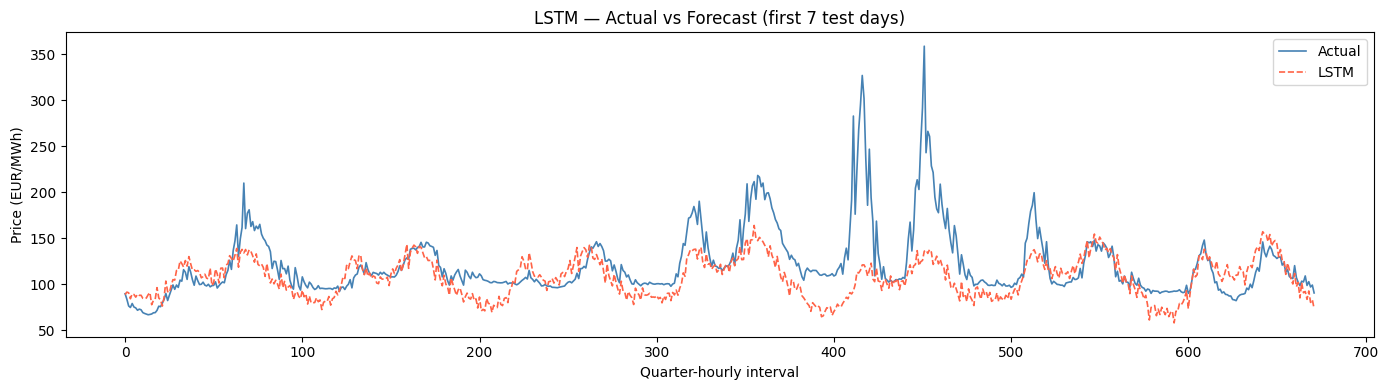

Plot saved


In [14]:
n_days = 7
n_plot = n_days * nintervals

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_test_orig.flatten()[:n_plot], label="Actual", linewidth=1.2, color="steelblue")
ax.plot(y_pred_orig.flatten()[:n_plot], label="LSTM",   linewidth=1.2, color="tomato", linestyle="--")
ax.set_title("LSTM — Actual vs Forecast (first 7 test days)")
ax.set_xlabel("Quarter-hourly interval")
ax.set_ylabel("Price (EUR/MWh)")
ax.legend()
plt.tight_layout()
plt.savefig(output_dir / "LSTM_forecast_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved")

# Step 10 - Save results 

In [15]:
lstm_dict = {
    "model_name" : "LSTM",
    "prediction" : y_pred_orig,
    "y_test"     : y_test_orig,
    "offset"     : offset_y,
    "scale"      : scale_y,
    "mae"        : mae,
    "test_days"  : [str(d) for d in test_days],
}

with open(output_dir / "LSTM.pkl", "wb") as f:
    pickle.dump([lstm_dict], f)

print(f"Saved: {output_dir / 'LSTM.pkl'}")
print("LSTM.ipynb complete")

Saved: ..\data\results\LSTM.pkl
LSTM.ipynb complete
